In [1]:
import re, os, sys, glob, warnings, gc, pickle, argparse, random
from pathlib import Path
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta

import numpy as np, pandas as pd
import pyarrow as pa, pyarrow.feather as pf, pyarrow.compute as pc

import torch, torch.nn.functional as F
from torch import nn
from numpy.linalg import eigh

import matplotlib.pyplot as plt

import numpy.core.numeric as _ncn
if 'numpy._core.numeric' not in sys.modules:
    sys.modules['numpy._core.numeric'] = _ncn

warnings.filterwarnings("ignore")
plt.style.use('default')  # 防止深色主题影响图表背景


In [2]:
# 从 model.py 导入共享配置（路径、因子名、标签名、预加载数据）
from model import (PROJECT_ROOT, root_path, fac_path as _fac_dir, fac_name,
                   label_path, label_name, liquid_path, liquid_name, params,
                   PredictModel, parse_args)

# ── Analysis-only 配置 ──
fac_path = _fac_dir + fac_name + '.fea'    # 因子数据完整路径
ret_1d_name = r'label_ret_1d'              # 回测用的实际 1 日收益

start = '20250101'
end = '20260331'
calendar_path = PROJECT_ROOT + 'data/calendar.parquet'
watchlist_path = PROJECT_ROOT + 'MyCode.txt'

model_test_path = rf'{root_path}/model_test'
model_res_path = rf'{root_path}/model_res'
model_train_base = rf'{root_path}/model_train'

bench1_path = PROJECT_ROOT + "Model/bench/20260618.fea"
bench2_path = None
bench3_path = None
bench4_path = None

PERSONAL_TOP_N = 1           # 个人模式持仓股票数
TOP_N = 1                 # 买入股票数量
EXCLUDE_LIMIT_UP = False  # 是否排除涨停板（涨幅>=9.5%）
LABEL_HORIZON_DAYS = 1     # 持仓天数：单日换手（1天）
SEASON = '2026q2'         # 预测季度



In [3]:
# ============================================================
# 所有函数与类定义（引擎函数 + 分析函数）
# ============================================================

# ── 引擎基础函数 ──────────────────────────────────────────────

_VAL_WEI_RE = re.compile(r'val_wei=(-?\d+\.\d+)')

def load_feature_map(model_test_path):
    import glob as _glob
    feat_path = os.path.join(model_test_path, 'feature_map.fea')
    if not os.path.exists(feat_path): return None
    factor_order = []
    with open(feat_path, 'r') as f:
        raw = f.read()
    raw = raw.replace('\\n', '\n')
    for line in raw.split('\n'):
        line = line.strip()
        if '=' in line:
            name, idx = line.rsplit('=', 1)
            factor_order.append((int(idx.strip()), name.strip()))
    factor_order.sort(key=lambda x: x[0])
    return [name for _, name in factor_order]

# ── Data preprocessing ─────────────────────────────────────────────────

def normed_data(data, factor_list):
    valid_threshold = max(1, int(0.1 * len(factor_list)))
    valid_mask = data[factor_list].notna().sum(axis=1) >= valid_threshold
    data = data.loc[valid_mask].copy()
    code_value = data['Code'].values; data_X = data[factor_list]
    quantiles = data_X.quantile([0.005, 0.995])
    data_X = data_X.clip(lower=quantiles.loc[0.005], upper=quantiles.loc[0.995], axis=1)
    data_X = (data_X - data_X.mean()) / data_X.std()
    data_X = data_X.fillna(0)
    data_x_np = np.nan_to_num(data_X.to_numpy(dtype=np.float32, copy=False), nan=0.0, posinf=0.0, neginf=0.0)
    return torch.from_numpy(data_x_np), code_value

def load_model(checkpoint_path, input_dim, **kwargs):
    """Load a trained checkpoint. Extra kwargs accepted for backward compatibility."""
    checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
    state_dict = checkpoint['state_dict']
    model_state = {k.removeprefix('model.'): v for k, v in state_dict.items() if k.startswith('model.')}
    model = PredictModel(input_dim=input_dim, **kwargs)
    missing, unexpected = model.load_state_dict(model_state, strict=False)
    if missing: print(f'[load_model] WARNING: missing keys (will use random init): {list(missing)[:10]}...')
    if unexpected:
        print(f"[load_model] WARNING: unexpected keys in checkpoint (will be ignored): {unexpected}")
    model.eval()
    return model

def find_best_checkpoint(fold_dir):
    ckpt_files = glob.glob(os.path.join(fold_dir, '**', '*.ckpt'), recursive=True)
    if not ckpt_files: raise FileNotFoundError(f'No ckpt under {fold_dir}')
    best_ckpt, best_val = None, -float('inf')
    for ckpt in ckpt_files:
        m = _VAL_WEI_RE.search(os.path.basename(ckpt))
        if m is None: continue
        val = float(m.group(1))
        if val > best_val: best_val = val; best_ckpt = ckpt
    if best_ckpt is None: raise RuntimeError(f'No val_wei parsed under {fold_dir}')
    return best_ckpt, best_val

def discover_folds(model_dir):
    folds = sorted(glob.glob(os.path.join(model_dir, 'fold[0-9]*')))
    if not folds: raise FileNotFoundError(f'No folds under {model_dir}')
    return folds

def predict_date(model, date, all_data, factor_list):
    data = all_data.loc[date].copy()
    data_X, code_value = normed_data(data, factor_list)
    with torch.no_grad():
        try:
            output = model(data_X, training_views=False)
        except TypeError:
            output = model(data_X)
        # Handle generic model output formats:
        # - tensor: use directly (e.g. V3.2 simple MLP)
        # - tuple with list: stack+mean (e.g. V3.0 multi-view training mode)
        # - tuple with tensor: use first (e.g. V3.0 inference mode)
        if isinstance(output, tuple):
            first = output[0]
            score = torch.stack(first, dim=0).mean(dim=0) if isinstance(first, list) else first
        elif isinstance(output, list):
            score = torch.stack(output, dim=0).mean(dim=0)
        else:
            score = output
    result = pd.DataFrame(score.detach().cpu().numpy(), index=code_value, columns=['value'])
    result.index.name = 'Code'
    return result

def predict_dates(dates, fac_path, model_train_base, season='2026q2', model_test_path=None):
    if not dates: return None
    if model_test_path is None: model_test_path = model_train_base.replace('model_train', 'model_test')
    train_factors = load_feature_map(model_test_path)
    if train_factors is not None:
        all_cols = pd.read_feather(fac_path, columns=[]).columns.tolist()
        available = [f for f in train_factors if f in all_cols]
        missing = [f for f in train_factors if f not in all_cols]
        if missing: print(f"[predict] WARNING: {len(missing)} training factors missing, will fill with 0")
        cols_to_load = ['date', 'Code'] + available
        print(f"[predict] Using {len(available)}/{len(train_factors)} factors")
    else:
        cols_to_load = None
        missing = []
    import pyarrow as pa, pyarrow.feather as pf, pyarrow.compute as pc
    table = pf.read_table(fac_path, columns=cols_to_load)
    mask = pc.is_in(table.column('date'), pa.array(dates))
    table = table.filter(mask)
    all_data = table.to_pandas(); del table
    all_data = all_data.set_index('date', drop=True).sort_index()
    # FIX: fill missing training factors with 0 to match model input dimension
    if train_factors is not None and missing:
        for f in missing:
            all_data[f] = 0.0
    factor_list = train_factors if train_factors is not None else [c for c in all_data.columns if c != 'Code']
    try: bias_idx = factor_list.index('bias_20')
    except ValueError: bias_idx = None

    model_dir = os.path.join(model_train_base, season)
    folds = discover_folds(model_dir)
    print(f"[predict] Using {len(folds)} folds")
    models = {}
    for fold_dir in folds:
        fn = os.path.basename(fold_dir)
        ckpt, val = find_best_checkpoint(fold_dir)
        print(f"[predict]   [{fn}] {os.path.basename(ckpt)} (val_wei={val:.4f})")
        models[fn] = load_model(ckpt, len(factor_list), near_limit_up_idx=bias_idx)

    new_scores = []
    for date in dates:
        if date not in all_data.index: continue
        fold_preds = [predict_date(m, date, all_data, factor_list) for m in models.values()]
        zscored = [(f - f.mean()) / f.std() for f in fold_preds]
        ensemble = sum(zscored)
        date_score = ensemble['value']; date_score.name = date
        new_scores.append(date_score)
        print(f"[predict]   [{date}] done, {len(ensemble)} stocks")
    if not new_scores: return None
    new_score_df = pd.DataFrame(new_scores); new_score_df.index.name = 'date'
    print(f"[predict] Done, {len(new_score_df)} days.")
    return new_score_df

def _load_trading_dates(calendar_path):
    cal = pd.read_parquet(calendar_path)
    return set(cal[cal['is_open'] == 1]['date'].astype(str).str.replace('-', '').tolist())

def save_predictions(score_df, output_dir):
    os.makedirs(output_dir, exist_ok=True)
    for date in score_df.index:
        s = score_df.loc[date].copy(); s.index.name = 'Code'
        s.to_pickle(os.path.join(output_dir, f'{date}.pkl'))

def concat_model_4fold(test_path, res_path):
    market = 'ALL'; cache_path = rf"{res_path}/{market}_zscore_score.fea"
    if os.path.exists(cache_path): return pd.read_feather(cache_path).set_index("date")
    model_res = []
    for fold in range(1, 5):
        fold_dirs = [d for d in os.listdir(test_path) if d == f'fold{fold}']
        if len(fold_dirs) == 0: continue
        data_path = rf"{test_path}/{fold_dirs[0]}"
        date_list = sorted(set([x[:8] for x in os.listdir(data_path)]))
        all_res = []
        for date in date_list:
            date_res = pd.read_pickle(f'{data_path}/{date}.pkl').T
            date_res.index = [date] * len(date_res)
            all_res.append(date_res)
        all_res = pd.concat(all_res, axis=0).sort_index()
        all_res.index.name = "date"
        model_res.append(all_res.apply(lambda x: (x - x.mean()) / x.std(), axis=1))
    model_res = sum(model_res)
    os.makedirs(res_path, exist_ok=True)
    model_res.reset_index().to_feather(cache_path)
    return model_res

def get_ret_ic(score, ret_data, start='20230101', end='20241231', top_n=1):
    """回测函数: ALL-IN Top-N 股票, 等权平均隔日收益, 无流动性约束.

    Returns:
        ret_series: 日均收益率 (百分比, 例如 0.5 = 0.5%)
        ic_series:  IC 序列
    """
    model_score = score.copy()
    label_ret, ic, datelist = [], [], []
    for date in model_score.loc[start:end].index:
        datelist.append(date)
        code_rank = model_score.loc[date].sort_values(ascending=False)
        ret = ret_data.loc[date].reindex(code_rank.index).fillna(0)

        # ALL-IN: 选 Top-N 只, 等权, 收益率 ×100 统一为百分比
        selected = code_rank.index[:top_n]
        daily_r = ret[selected].mean() * 100

        label_ret.append(daily_r)
        ic.append(code_rank.corr(ret * 100))
    return pd.Series(label_ret, index=datelist, dtype='float'), pd.Series(ic, index=datelist, dtype='float')

def get_metrics(ret, ic):
    return {"IC": ic.mean(), "ICIR": ic.mean() / ic.std() if ic.std() != 0 else 0,
            "top_return": ret.mean(), "top_return_stability": ret.mean() / ret.std() if ret.std() != 0 else 0}

def ensemble_scores(*dfs):
    result_list = []
    for i, df in enumerate(dfs, 1):
        df_norm = df.copy().apply(lambda x: (x - x.mean()) / x.std(), axis=1)
        result_list.append(df_norm.stack().rename(f"score{i}"))
    return pd.concat(result_list, axis=1).dropna()

def run_individual_strategy(model_score, ret_data, top_n=5, exclude_limit_up=True,
                            limit_up_threshold=0.095, start='20230101', end='20260331'):
    model_score_sub = model_score.loc[start:end]
    daily_ret, skip_total, skip_days, datelist = [], 0, 0, []
    for date in model_score_sub.index:
        ranked = model_score_sub.loc[date].sort_values(ascending=False)
        selected, skipped = [], 0
        for code in ranked.index:
            if len(selected) >= top_n: break
            if exclude_limit_up:
                r_val = ret_data.loc[date, code] if code in ret_data.columns else 0.0
                if pd.notna(r_val) and r_val >= limit_up_threshold: skipped += 1; continue
            selected.append(code)
        r = ret_data.loc[date, selected].mean() if len(selected) > 0 else 0.0
        datelist.append(date); daily_ret.append(r)
        skip_total += skipped
        if skipped > 0: skip_days += 1
    daily_ret = pd.Series(daily_ret, index=datelist, dtype='float')
    stats = {'skip_total': skip_total, 'skip_days': skip_days, 'total_days': len(datelist),
             'skip_day_pct': skip_days / len(datelist) * 100 if len(datelist) > 0 else 0}
    return daily_ret, stats

# ── 分析函数 ──────────────────────────────────────────────────


def print_quarterly_metrics(ret, ic):
    """打印每个季度的收益和IC指标"""
    ret_series = ret.copy()
    ic_series = ic.copy()
    ret_series.index = pd.to_datetime(ret_series.index)
    ic_series.index = pd.to_datetime(ic_series.index)
    quarterly_ret = ret_series.groupby(pd.Grouper(freq='QE')).mean()
    quarterly_ic = ic_series.groupby(pd.Grouper(freq='QE')).mean()
    quarterly_ret.index = [f"{idx.year}Q{idx.quarter}" for idx in quarterly_ret.index]
    quarterly_ic.index = [f"{idx.year}Q{idx.quarter}" for idx in quarterly_ic.index]
    quarterly_df = pd.DataFrame({
        '季度平均收益': quarterly_ret.round(4),
        '季度平均IC': quarterly_ic.round(4)
    })
    print("\n===== 季度表现指标 =====")
    print(quarterly_df)
    print("=======================\n")


def print_metrics(model_metrics, bench_metrics=None, title="模型评估结果"):
    metric_keys = list(model_metrics.keys())
    df = pd.DataFrame(index=metric_keys)
    df.index.name = "指标"
    df["模型值"] = [model_metrics[k] for k in metric_keys]
    if bench_metrics is not None:
        df["基准值"] = [bench_metrics.get(k, None) for k in metric_keys]
        df["提升值"] = ((df["模型值"] - df["基准值"]) / df["基准值"]) * 100
    print(f"\n{title}")
    print(df.round(4))


def plot_model(model_score, bench_score, ret_1d_data, start='20250101', end='20260331', top_n=1):
    model_ret, _ = get_ret_ic(model_score, ret_1d_data, start=start, end=end, top_n=top_n)
    model_ret = model_ret / 100
    bench_ret, _ = get_ret_ic(bench_score, ret_1d_data, start=start, end=end, top_n=top_n)
    bench_ret = bench_ret / 100

    # 对齐日期：取两个序列的交集，避免 model_score / bench_score 日期不一致
    common_idx = model_ret.index.intersection(bench_ret.index)
    model_ret = model_ret.loc[common_idx]
    bench_ret = bench_ret.loc[common_idx]

    dates = model_ret.index.tolist()
    seen_months = set()
    month_ticks = []
    month_labels = []
    for i, d in enumerate(dates):
        month = d[:6]
        if month not in seen_months:
            seen_months.add(month)
            month_ticks.append(i)
            month_labels.append(d)

    # 1. 每日收益率曲线
    plt.figure(figsize=(12, 6))
    plt.plot(dates, model_ret.cumsum(), label='model', color='blue')
    plt.plot(dates, bench_ret.cumsum(), label='bench', color='orange')
    plt.title('Cumulative Return Of Model & Bench', fontsize=14)
    plt.ylabel('Cumulative Return', fontsize=12)
    plt.xticks(ticks=month_ticks, labels=month_labels, rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 2. 相对提升
    plt.figure(figsize=(12, 6))
    relative_improvement = model_ret - bench_ret
    plt.plot(dates, relative_improvement.cumsum(), label='model', color='blue')
    plt.title('Relative Improvement', fontsize=14)
    plt.ylabel('Relative Improvement', fontsize=12)
    plt.xticks(ticks=month_ticks, labels=month_labels, rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()
# ---- 辅助函数 ----
def print_strategy(label, ret_series):
    ann = ret_series.mean() * 252 * 100
    sharpe = (ret_series.mean() / ret_series.std() * np.sqrt(252)
              if ret_series.std() > 0 else 0)
    q_avg = ret_series.groupby(
        pd.to_datetime(ret_series.index).to_period('Q')
    ).mean().mean() * 100
    print(f"{label:<35} {ann:>8.2f}% {sharpe:>8.4f} {q_avg:>10.4f}%")


def load_bench(bench_path):
    if bench_path is not None and os.path.exists(bench_path):
        return pd.read_feather(bench_path).set_index("date")
    return None

def run_new_top1_open_red(model_score, ret_data, open_red_dict, start, end):
    """new_Top 1: 从模型得分最高的股票中，选出当天开盘红的第一个（只买一只）。

    Args:
        ret_data: 应为 label_ret_1d（实际 1 日收益），非训练 target
    """
    model_score_sub = model_score.loc[start:end]
    daily_ret, datelist, hit_days = [], [], 0
    for date in model_score_sub.index:
        ranked = model_score_sub.loc[date].sort_values(ascending=False)
        red_set = open_red_dict.get(date, set())
        if not red_set:
            datelist.append(date)
            daily_ret.append(0.0)
            continue
        selected = None
        for code in ranked.index:
            if code in red_set:
                selected = code
                break
        if selected is not None:
            r = ret_data.loc[date, selected] if selected in ret_data.columns else 0.0
            hit_days += 1
        else:
            r = 0.0
        datelist.append(date)
        daily_ret.append(r)
    ret_series = pd.Series(daily_ret, index=datelist, dtype='float')
    print(f"  new_Top 1 (开盘红): 共 {len(datelist)} 天, 命中 {hit_days} 天 ({hit_days/len(datelist)*100:.1f}%)")
    return ret_series


# 原始 Top 1/3/5/10/20 —— 使用实际 1 日收益

def get_nth_next_trade_date(date_str, n=1):
    """获取 date_str 之后第 n 个交易日"""
    try:
        idx = _trade_dates.index(date_str)
        if idx + n < len(_trade_dates):
            return _trade_dates[idx + n]
    except (ValueError, IndexError):
        pass
    return None

def fmt_date(date_str):
    if date_str is None:
        return "待定（交易日历未覆盖）"
    return f"{date_str[:4]}年{int(date_str[4:6])}月{int(date_str[6:8])}日"

def _next_td(date_str, n=1):
    """Get the n-th trading day after (n>0) or before (n<0) date_str."""
    try:
        idx = _td_list.index(date_str)
        t = idx + n
        if 0 <= t < len(_td_list):
            return _td_list[t]
    except (ValueError, IndexError):
        pass
    return None


# ── CJK-aware display helpers ──────────────────────────────────────────

def _cjk_width(s):
    """Display width: CJK chars ≈ 2, ASCII ≈ 1."""
    w = 0
    for ch in str(s):
        w += 2 if ord(ch) > 127 else 1
    return w

def _pad_cjk(s, w, align='<'):
    """Pad string to display width w, accounting for CJK characters."""
    s = str(s)
    cur = _cjk_width(s)
    pad = max(0, w - cur)
    if align == '>': return ' ' * pad + s
    elif align == '^': l = pad // 2; r = pad - l; return ' ' * l + s + ' ' * r
    return s + ' ' * pad


# ── Backtest shared utilities ──────────────────────────────────────────

def _load_daily_adj():
    """Load daily_adj price data (cached). Returns DataFrame."""
    DAILY_ADJ_PATH = "/root/autodl-fs/lingqiData/data/daily_adj.parquet"
    try:
        return daily_adj
    except NameError:
        pass
    df = pd.read_parquet(DAILY_ADJ_PATH)
    df['trade_date'] = df['trade_date'].str.replace('-', '')
    df['code_clean'] = df['stock_code'].str.replace('.SZ', '').str.replace('.SH', '')
    df = df.sort_values(['code_clean', 'trade_date'])
    df['prev_close'] = df.groupby('code_clean')['close'].shift(1)
    return df


def _load_name_map():
    """Load stock code → name mapping (cached). Returns dict."""
    try:
        return code_to_name
    except NameError:
        pass
    stock_info = pd.read_parquet(PROJECT_ROOT + 'data/list.parquet')
    stock_info = stock_info[stock_info['list_status'] == 'L']
    return {
        re.sub(r'\.(SZ|SH|BJ)$', '', row['stock_code']): row['name']
        for _, row in stock_info.iterrows()
    }


def load_backtest_setup():
    """Load all shared data for backtest cells: price maps + name map.
    
    Also initializes module-level _td_list (used by _next_td) and _trade_dates
    (used by get_nth_next_trade_date).

    Returns:
        close_map      : dict (trade_date, code_clean) → close
        prev_close_map : dict (trade_date, code_clean) → prev_close
        code_to_name   : dict code → name
    """
    global _td_list, _trade_dates
    
    # --- Calendar ---
    cal = pd.read_parquet(PROJECT_ROOT + 'data/calendar.parquet')
    cal = cal[cal['is_open'] == 1]
    _td_list = sorted(cal['date'].astype(str).str.replace('-', '').tolist())
    _trade_dates = _td_list  # alias for get_nth_next_trade_date compatibility
    
    # --- Price data ---
    df = _load_daily_adj()
    print(f"Price data: {len(df)} rows, "
          f"dates {df['trade_date'].min()} ~ {df['trade_date'].max()}")

    close_map      = df.set_index(['trade_date', 'code_clean'])['close'].to_dict()
    prev_close_map = df.set_index(['trade_date', 'code_clean'])['prev_close'].to_dict()
    code_to_name   = _load_name_map()

    return close_map, prev_close_map, code_to_name


def build_trade_log_df(model_score_extended, recent_dates, close_map, prev_close_map,
                        code_to_name, top_n=1, exclude_limit_up=False, label_horizon_days=1):
    """Build trade log records and daily return series from model scores & price data.

    Returns:
        trade_df   : DataFrame with columns [FactorDt, BuyDt, Code, Name, Score,
                     BuyPrc, SellDt, SellPrc, Ret%, 累加收益]
        ret_valid  : Series of realized daily returns
        skip_total : int, number of stocks skipped by limit-up filter
        skip_days  : int, number of days with at least one skip
    """
    records = []
    daily_returns = {}
    skip_total = 0
    skip_days = 0

    for date in recent_dates:
        scores = model_score_extended.loc[date].sort_values(ascending=False)

        # Stock selection: top N by model score
        picked = []
        day_skipped = 0
        for code in scores.index:
            if len(picked) >= top_n:
                break
            if exclude_limit_up:
                fc = close_map.get((date, code))
                pc = prev_close_map.get((date, code))
                if fc is not None and pc is not None and pc > 0:
                    if fc / pc - 1.0 >= 0.095:
                        day_skipped += 1
                        continue
            picked.append(code)
        if day_skipped > 0:
            skip_days += 1
            skip_total += day_skipped

        day_rets = []
        for rank_i, code in enumerate(picked):
            score = scores[code]
            buy_date = _next_td(date, 1)
            sell_date = _next_td(buy_date, label_horizon_days) if buy_date else None

            buy_price  = close_map.get((buy_date, code)) if buy_date else None
            sell_price = close_map.get((sell_date, code)) if sell_date else None

            if buy_price is not None and sell_price is not None and buy_price > 0:
                ret_val = sell_price / buy_price - 1.0
                ret_src  = 'OK'
            else:
                ret_val = None
                ret_src  = 'pending'

            day_rets.append(ret_val)

            name = code_to_name.get(code, '?')
            records.append({
                'factor_dt': date,
                'buy_dt':    buy_date or '-',
                'code':      code,
                'name':      name,
                'score':     score,
                'buy_prc':   buy_price,
                'sell_dt':   sell_date or '-',
                'sell_prc':  sell_price,
                'ret_pct':   ret_val * 100.0 if ret_val is not None else None,
                'status':    ret_src,
            })

        # Strategy daily return = mean of picked stocks' returns
        valid = [r for r in day_rets if r is not None]
        daily_returns[date] = float(np.mean(valid)) if valid else None

    # Build return series
    ret_series = pd.Series(daily_returns, name='daily_return').sort_index()
    ret_valid = ret_series.dropna()

    # Build trade_df
    disp_cols = {
        'factor_dt': 'FactorDt', 'buy_dt': 'BuyDt', 'code': 'Code',
        'name': 'Name', 'score': 'Score', 'buy_prc': 'BuyPrc',
        'sell_dt': 'SellDt', 'sell_prc': 'SellPrc', 'ret_pct': 'Ret%',
    }
    trade_df = pd.DataFrame(records).rename(columns=disp_cols)

    # Cumulative additive return
    cum = 0.0
    cum_list = []
    for _, row in trade_df.iterrows():
        val = row['Ret%']
        if pd.notna(val):
            cum += val
        cum_list.append(cum)
    trade_df['累加收益'] = cum_list
    trade_df = trade_df[list(disp_cols.values()) + ['累加收益']]

    return trade_df, ret_valid, skip_total, skip_days


def plot_backtest_curve(ret_valid, start_d, end_d, top_n=1, label_horizon_days=1,
                         predicted_dates=None):
    """Plot cumulative return + daily return bar chart."""
    dates_plot = ret_valid.index.tolist()
    vals_plot = ret_valid.values

    if len(dates_plot) == 0:
        print("\nWARNING: no return data available, skipping plot.")
        return

    step = max(1, len(dates_plot) // 10)
    tick_idx = list(range(0, len(dates_plot), step))
    tick_lbl = [dates_plot[i] for i in tick_idx]

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Left: Cumulative return
    cum = np.cumsum(vals_plot)
    axes[0].plot(dates_plot, cum, color='#1f77b4', linewidth=1.8, marker='o', markersize=3)
    axes[0].fill_between(range(len(dates_plot)), 0, cum, alpha=0.10, color='#1f77b4')
    axes[0].axhline(y=0, color='gray', linestyle='--', linewidth=0.8)
    if predicted_dates:
        p0 = predicted_dates[0]
        if p0 in dates_plot:
            axes[0].axvline(x=p0, color='red', linestyle='--', alpha=0.5, linewidth=1.2)
    axes[0].set_title(f'Top {top_n} Cumulative Return | {start_d} ~ {end_d}', fontsize=13)
    axes[0].set_ylabel('Cumulative Return', fontsize=11)
    axes[0].set_xticks(tick_idx)
    axes[0].set_xticklabels(tick_lbl, rotation=45, ha='right')
    axes[0].grid(True, alpha=0.3)

    # Right: Daily return
    bar_colors = ['#d62728' if v < 0 else '#2ca02c' for v in vals_plot]
    axes[1].bar(range(len(dates_plot)), vals_plot, color=bar_colors, alpha=0.80, width=0.65)
    axes[1].axhline(y=0, color='black', linewidth=0.8)
    axes[1].set_title(f'Daily Return ({label_horizon_days}d holding)', fontsize=13)
    axes[1].set_ylabel('Daily Return', fontsize=11)
    axes[1].set_xticks(tick_idx)
    axes[1].set_xticklabels(tick_lbl, rotation=45, ha='right')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def print_trade_log_table(trade_df, ret_valid, recent_dates, top_n=1, label_horizon_days=1):
    """Print CJK-aligned trade log table with cumulative return."""
    print(f"\n{'='*100}")
    print(f"  Trade Log — Top {top_n} | {len(recent_dates)} days | "
          f"hold {label_horizon_days}d | Returns from daily_adj close prices")
    print(f"{'='*100}")

    # Format
    fmt_df = trade_df.copy()
    fmt_df['Score']   = fmt_df['Score'].apply(lambda x: f'{x:+.2f}' if pd.notna(x) else '-')
    fmt_df['BuyPrc']  = fmt_df['BuyPrc'].apply(lambda x: f'{x:.2f}' if pd.notna(x) else '-')
    fmt_df['SellPrc'] = fmt_df['SellPrc'].apply(lambda x: f'{x:.2f}' if pd.notna(x) else '-')
    fmt_df['Ret%']    = fmt_df['Ret%'].apply(lambda x: f'{x:+.2f}%' if pd.notna(x) else '-')
    fmt_df['累加收益'] = fmt_df['累加收益'].apply(
        lambda x: f'{x:+.2f}%' if abs(x) >= 0.01 else f'{x:+.4f}%')

    # Column widths & alignment
    _cols = fmt_df.columns.tolist()
    _col_align = {c: ('<' if c == 'Name' else '>') for c in _cols}
    _col_w = [max(_cjk_width(c), max((_cjk_width(str(v)) for v in fmt_df[c]), default=0)) + 2
              for c in _cols]

    # Header (centered), separator, rows (numbers right, names left)
    print(''.join(_pad_cjk(c, _col_w[i], '^') for i, c in enumerate(_cols)))
    print(''.join('-' * _col_w[i] for i in range(len(_cols))))
    for _, row in fmt_df.iterrows():
        print(''.join(_pad_cjk(str(row[c]), _col_w[i], _col_align[c]) for i, c in enumerate(_cols)))

    print(f"{'='*100}\n")

    # Quick stats
    n_ok   = len(ret_valid)
    n_pend = len(recent_dates) - n_ok
    print(f"Realized: {n_ok}  |  Pending: {n_pend}")

    if len(ret_valid) > 0:
        cum_r = ret_valid.sum()
        win_r = int((ret_valid > 0).sum())
        print(f"Cumulative: {cum_r:+.4f} ({cum_r*100:+.2f}%)  |  "
              f"Win rate: {win_r}/{len(ret_valid)} ({win_r/len(ret_valid)*100:.1f}%)  |  "
              f"Mean: {ret_valid.mean():+.6f}  |  "
              f"MaxDD: {(np.cumsum(ret_valid.values) - np.maximum.accumulate(np.cumsum(ret_valid.values))).min():.4f}")
    print()


def print_backtest_summary(ret_valid, recent_dates, start_d, end_d, n_lookback,
                            top_n=1, label_horizon_days=1,
                            skip_total=0, skip_days=0, exclude_limit_up=False):
    """Print backtest summary statistics."""
    total_days = len(recent_dates)
    valid_days = len(ret_valid)
    pending_days = total_days - valid_days

    if valid_days > 0:
        vals = ret_valid.values
        win_days = int((vals > 0).sum())
        cum_ret = float(vals.sum())
        cummax_track = np.maximum.accumulate(np.cumsum(vals))
        drawdown = np.cumsum(vals) - cummax_track
        max_dd = float(drawdown.min())
        max_dd_idx = int(drawdown.argmin())
        best_idx = int(vals.argmax())
        worst_idx = int(vals.argmin())
        ann_ret = float(vals.mean() * 252 * 100)
        ann_sharpe = float(vals.mean() / vals.std() * np.sqrt(252)) if vals.std() > 0 else 0.0
        win_rate = win_days / valid_days * 100
    else:
        win_days = cum_ret = max_dd = ann_ret = ann_sharpe = win_rate = 0.0
        best_idx = worst_idx = max_dd_idx = 0

    print(f"{'='*55}")
    print(f"  Recent {n_lookback}d Summary  |  Top {top_n}  |  Hold {label_horizon_days}d")
    print(f"{'='*55}")
    print(f"  Window     : {start_d} ~ {end_d}  ({total_days} days)")
    print(f"  Realized   : {valid_days} days  |  Pending : {pending_days} days")
    if valid_days > 0:
        print(f"  Cum Return : {cum_ret:+.4f}  ({cum_ret*100:+.2f}%)")
        print(f"  Daily Mean : {vals.mean():+.6f}  ({vals.mean()*100:+.4f}%)")
        print(f"  Ann Return : {ann_ret:.2f}%")
        print(f"  Sharpe     : {ann_sharpe:.4f}")
        print(f"  Win Rate   : {win_rate:.1f}%  ({win_days}/{valid_days})")
        print(f"  Best Day   : {vals[best_idx]:+.4f}  ({ret_valid.index[best_idx]})")
        print(f"  Worst Day  : {vals[worst_idx]:+.4f}  ({ret_valid.index[worst_idx]})")
        if max_dd < 0:
            print(f"  Max Drawdown: {max_dd:.4f}  ({max_dd*100:.2f}%)  at {ret_valid.index[max_dd_idx]}")
        else:
            print(f"  Max Drawdown: 0 (no drawdown)")
    print(f"{'='*55}\n")

    # Pending-dates detail
    if pending_days > 0:
        pending_list = [d for d in recent_dates if d not in ret_valid.index]
        print(f"[Pending] {pending_days} date(s) — {label_horizon_days}d return not yet realized:")
        for d in pending_list:
            buy_d = _next_td(d, 1)
            sell_d = _next_td(buy_d, label_horizon_days) if buy_d else None
            print(f"  {d}: buy {buy_d or '?'}  ->  sell {sell_d or '?'}")
        print()

    # Limit-up filter stats
    if exclude_limit_up and skip_total > 0:
        print(f"[Limit-Up Filter] {skip_total} stocks filtered across "
              f"{skip_days}/{total_days} days ({skip_days/total_days*100:.1f}%)")


# 使用示例

---单一模型评估---
  持仓数: 1 只

===== 季度表现指标 =====
        季度平均收益  季度平均IC
2025Q1  2.3214  0.0592
2025Q2  1.7961  0.0563
2025Q3  1.4691  0.0558
2025Q4  0.3444  0.0471
2026Q1  1.4848  0.0488


模型评估结果
                         模型值
指标                          
IC                    0.0535
ICIR                  0.6064
top_return            1.4745
top_return_stability  0.2710


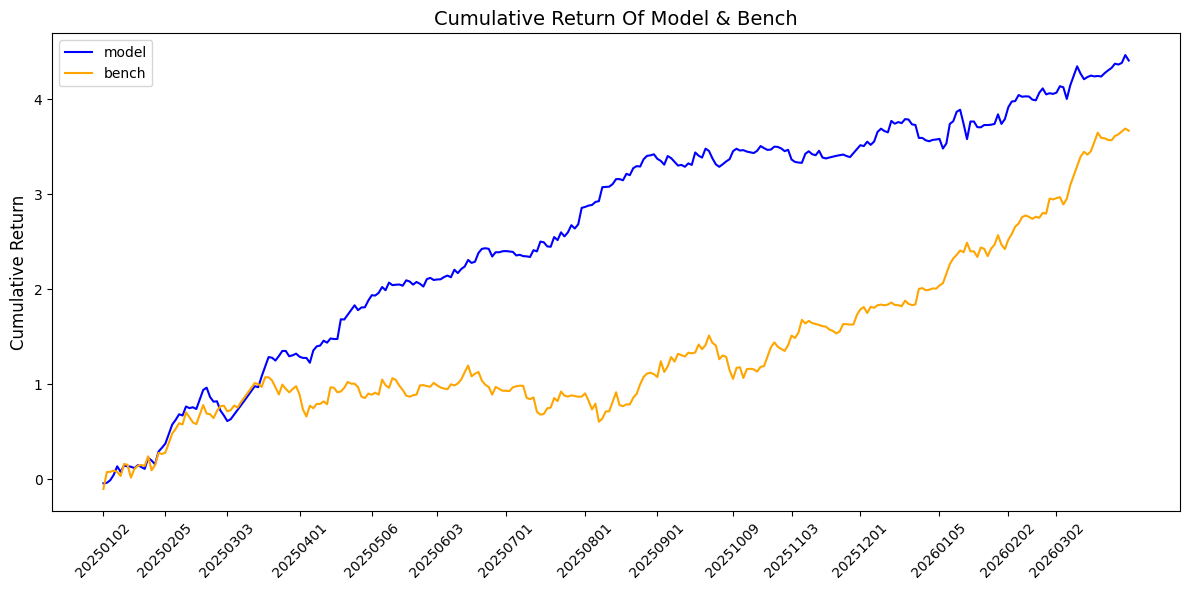

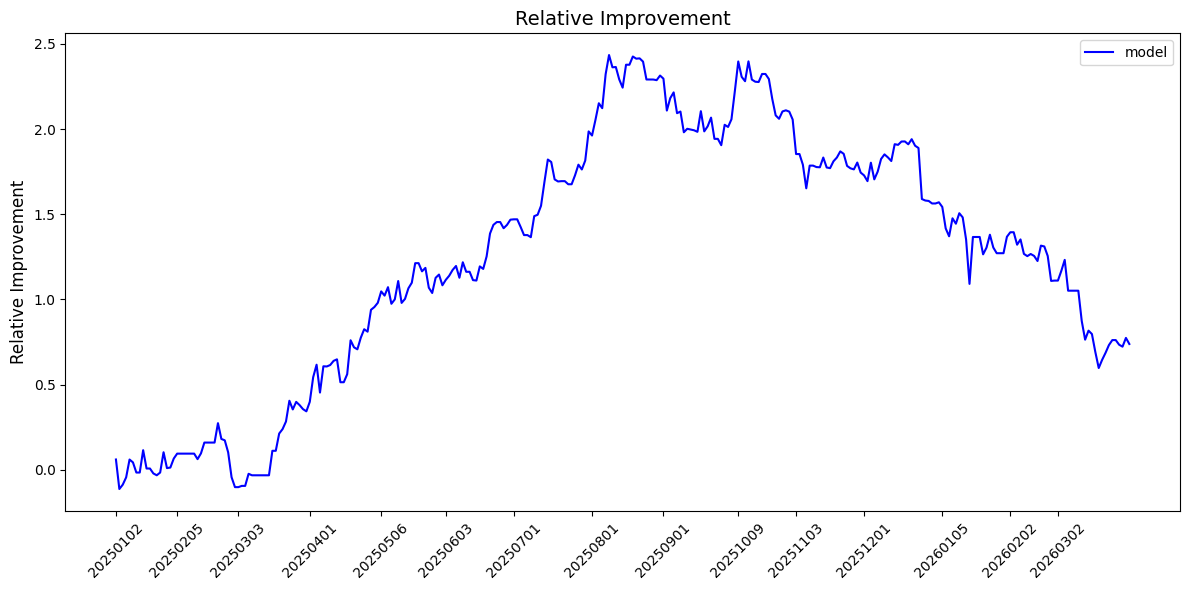

In [4]:



# bench
bench1 = load_bench(bench1_path)
bench2 = load_bench(bench2_path)
if bench2 == None:
    bench2 = bench1.copy()  
bench3 = load_bench(bench3_path)
if bench3 == None:
    bench3 = bench2.copy()
bench4 = load_bench(bench4_path)
if bench4 == None:
    bench4 = bench3.copy()

bench_all = ensemble_scores(bench1, bench2, bench3, bench4)
bench_all = bench_all.mean(axis=1).unstack()

# 收集模型训练结果
model_score = concat_model_4fold(test_path=model_test_path, res_path=model_res_path)
print("---单一模型评估---")
# 回测使用实际 1 日收益（单日换手），非训练 label
print(f"  持仓数: {PERSONAL_TOP_N} 只")
ret1, ic1 = get_ret_ic(model_score, params.ret_1d_data, start=start, end=end,
                       top_n=PERSONAL_TOP_N)
print_quarterly_metrics(ret1, ic1)
score1_metrics = get_metrics(ret1, ic1)
print_metrics(score1_metrics)
plot_model(model_score, bench_all, params.ret_1d_data, start=start, end=end,
           top_n=PERSONAL_TOP_N)


===== 加载 daily_adj 数据 =====
  开盘红字典覆盖 1815 个交易日

===== 多策略对比 =====
策略                                      年化收益     夏普比率       季均收益
-----------------------------------------------------------------
Top 1 (个人, 不过滤涨停)                     371.56%   4.3027     1.4832%
Top 3 (个人, 不过滤涨停)                     232.72%   4.7978     0.9233%
Top 5 (个人, 不过滤涨停)                     195.80%   4.7675     0.7729%
Top 10 (个人, 不过滤涨停)                    162.51%   4.7114     0.6378%
Top 20 (个人, 不过滤涨停)                    146.87%   4.8703     0.5755%
  new_Top 1 (开盘红): 共 299 天, 命中 299 天 (100.0%)
new_Top 1 (开盘红)                       319.34%   3.7178     1.2696%


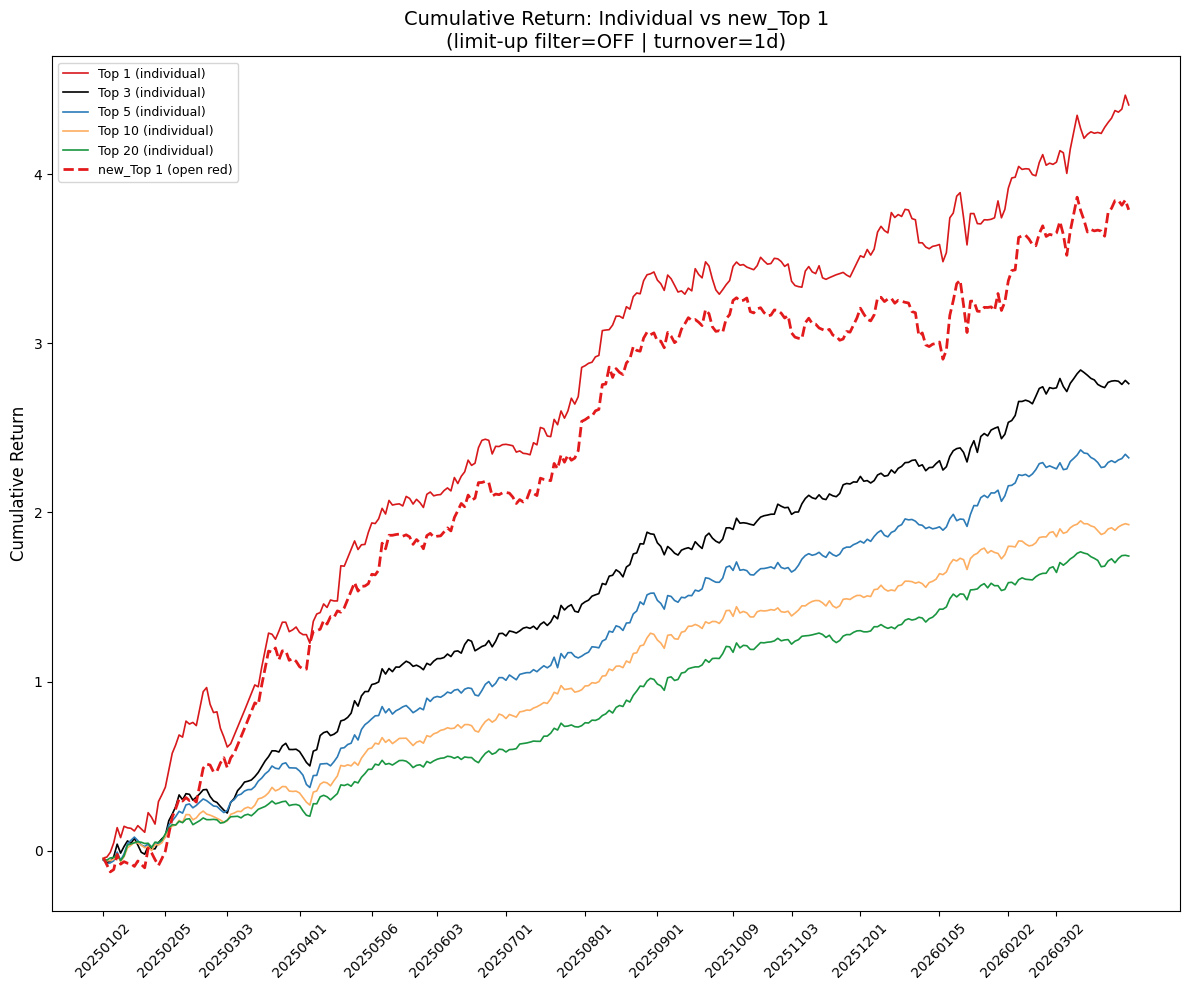

In [5]:
# ==== 加载开盘红数据（new_Top 1 需要）====
print("\n===== 加载 daily_adj 数据 =====")
daily_adj = _load_daily_adj()
daily_adj['open_red'] = daily_adj['open'] > daily_adj['prev_close']
red_open = daily_adj[daily_adj['open_red'] == True]
open_red_dict = red_open.groupby('trade_date')['code_clean'].apply(set).to_dict()
print(f"  开盘红字典覆盖 {len(open_red_dict)} 个交易日")


print("\n===== 多策略对比 =====")
print(f"{'策略':<35} {'年化收益':>8} {'夏普比率':>8} {'季均收益':>10}")
print("-" * 65)

# 原始 Top 1/3/5/10/20 —— 使用实际 1 日收益
individual_rets = {}
for n in [1, 3, 5, 10, 20]:
    r, s = run_individual_strategy(model_score, params.ret_1d_data, top_n=n,
                                          exclude_limit_up=EXCLUDE_LIMIT_UP,
                                          start=start, end=end)
    individual_rets[n] = r
    print_strategy(f"Top {n} (个人, 不过滤涨停)", r)

# new_Top 1: 只买一只 + 要求开盘红 —— 使用实际 1 日收益
r_new = run_new_top1_open_red(model_score, params.ret_1d_data, open_red_dict, start, end)
print_strategy("new_Top 1 (开盘红)", r_new)


# ---- 绘图对比 ----
dates = r_new.index.tolist()
seen_months = set()
month_ticks, month_labels = [], []
for i, d in enumerate(dates):
    month = d[:6]
    if month not in seen_months:
        seen_months.add(month)
        month_ticks.append(i)
        month_labels.append(d)

fig, axes = plt.subplots(1, 1, figsize=(12, 10))

colors = ['#d7191c', '#000000', '#2c7bb6', '#fdae61', '#1a9641']
for i, n in enumerate([1, 3, 5, 10, 20]):
    r = individual_rets[n]
    axes.plot(dates, r.cumsum(), label=f'Top {n} (individual)',
              color=colors[i], linewidth=1.2)

# 新增 new_Top 1 曲线（用加粗虚线突出）
axes.plot(dates, r_new.cumsum(), label='new_Top 1 (open red)',
          color='#e31a1c', linewidth=2.0, linestyle='--')

axes.set_title(
    f'Cumulative Return: Individual vs new_Top 1\n'
    f'(limit-up filter={"ON" if EXCLUDE_LIMIT_UP else "OFF"} | turnover=1d)',
    fontsize=14
)
axes.set_ylabel('Cumulative Return', fontsize=12)
axes.set_xticks(month_ticks)
axes.set_xticklabels(month_labels, rotation=45)
axes.legend(fontsize=9)

plt.tight_layout()
plt.show()


# 预测补充 & 最新推荐
自动检测 factor 数据中超出 model_res 覆盖范围的日期，使用最优模型进行预测，并展示最新打分结果与投资建议。

In [6]:
# ============================================================
# 1. 统一推演：一口气补充所有 model_res 未覆盖日期 + 历史一致性验证
# ============================================================

# --- 1a. 找出 model_res 未覆盖的因子日期 ---
last_date = str(model_score.index.max())
dates_df = pd.read_feather(fac_path, columns=['date'])
all_factor_dates = sorted(dates_df['date'].unique())
trading_dates = _load_trading_dates(calendar_path)
missing_dates = sorted([d for d in all_factor_dates if d > last_date and d in trading_dates])
non_trading = sorted([d for d in all_factor_dates if d > last_date and d not in trading_dates])

print(f"model_res 最新日期 : {last_date}")
print(f"因子数据最新日期   : {all_factor_dates[-1]}")
if non_trading:
    print(f"排除非交易日       : {len(non_trading)} 天 {non_trading}")
print(f"缺失交易日         : {len(missing_dates)} 天 {missing_dates if missing_dates else '(无)'}")

# --- 1b. 历史验证日期（model_test 最后 3 天） ---
hist_dates = sorted(model_score.index)[-3:]
print(f"历史验证日期       : {hist_dates}")

# --- 1c. 合并所有需推演的日期 → 一次调用 ---
all_to_predict = sorted(set(missing_dates + hist_dates))
predicted_all = None
if all_to_predict:
    print(f"\n>>> 统一推演 {len(all_to_predict)} 个日期: {all_to_predict[0]} ~ {all_to_predict[-1]}")
    predicted_all = predict_dates(all_to_predict, fac_path=fac_path,
                                          model_train_base=model_train_base,
                                          season=SEASON)
else:
    print(">>> 无需推演任何日期")

# --- 1d. 拆分结果：新增 vs 历史验证 ---
if predicted_all is not None:
    # ---- 新增预测 ----
    new_mask = predicted_all.index.isin(missing_dates)
    new_scores = predicted_all.loc[new_mask] if new_mask.any() else None

    # ---- 历史验证 ----
    hist_mask = predicted_all.index.isin(hist_dates)
    hist_scores = predicted_all.loc[hist_mask] if hist_mask.any() else None

    # ---- 扩展 model_score ----
    if new_scores is not None and len(new_scores) > 0:
        model_score_extended = pd.concat([model_score, new_scores], axis=0).sort_index()
        print(f"\n合并完成：原始 {len(model_score)} 天 + 新增 {len(new_scores)} 天 = {len(model_score_extended)} 天")
        print(f"新增日期: {list(new_scores.index)}")

        # 落盘到 model_pred
        pred_dir = rf'{root_path}/model_pred/{SEASON}'
        save_predictions(new_scores, pred_dir)
        print(f"已保存到: {pred_dir}")
    else:
        model_score_extended = model_score.copy()
        print("无新增日期，使用原始 model_score。")

    # ---- 历史一致性验证 ----
    if hist_scores is not None and len(hist_scores) > 0:
        # 落盘
        hist_dir = rf'{root_path}/model_pred/{SEASON}'
        save_predictions(hist_scores, hist_dir)

        print("\n--- 与 model_test 一致性验证 ---")
        for date in hist_dates:
            if date in hist_scores.index and date in model_score.index:
                old = model_score.loc[date]
                new = hist_scores.loc[date]
                common = old.index.intersection(new.index)
                if len(common) > 0:
                    corr = old[common].corr(new[common])
                    print(f"  {date}: corr={corr:.6f}, 共同股票数={len(common)}")
                else:
                    print(f"  {date}: 无共同股票")
            else:
                print(f"  {date}: 无预测结果")
else:
    model_score_extended = model_score.copy()
    print("推演无结果，使用原始 model_score。")


model_res 最新日期 : 20260610
因子数据最新日期   : 20260701
缺失交易日         : 14 天 ['20260611', '20260612', '20260615', '20260616', '20260617', '20260618', '20260622', '20260623', '20260624', '20260625', '20260626', '20260629', '20260630', '20260701']
历史验证日期       : ['20260608', '20260609', '20260610']

>>> 统一推演 17 个日期: 20260608 ~ 20260701
[predict] Using 960/960 factors
[predict] Using 4 folds
[predict]   [fold1] epoch=13-val_wei=3.1275.ckpt (val_wei=3.1275)
[predict]   [fold2] epoch=15-val_wei=2.9493.ckpt (val_wei=2.9493)
[predict]   [fold3] epoch=16-val_wei=2.5367.ckpt (val_wei=2.5367)
[predict]   [fold4] epoch=17-val_wei=2.3089.ckpt (val_wei=2.3089)
[predict]   [20260608] done, 1782 stocks
[predict]   [20260609] done, 1782 stocks
[predict]   [20260610] done, 1782 stocks
[predict]   [20260611] done, 1782 stocks
[predict]   [20260612] done, 1782 stocks
[predict]   [20260615] done, 1782 stocks
[predict]   [20260616] done, 1782 stocks
[predict]   [20260617] done, 1782 stocks
[predict]   [20260618] d

In [7]:
# ============================================================
# 2. 最新推荐展示：股票名称映射、Top 打分、投资建议
# ============================================================

# --- 股票代码 → 名称映射 ---
code_to_name = _load_name_map()

# --- 交易日历 ---
cal = pd.read_parquet(PROJECT_ROOT + 'data/calendar.parquet')
cal = cal[cal['is_open'] == 1]
_trade_dates = sorted(cal['date'].astype(str).str.replace('-', '').tolist())




# ============================================================
# 数据当前日期 & 预测日期推算
# ============================================================

# 原始 model_res 的最新日期（有真实 label 的最后一天）
last_label_date = model_score.index.max()

# 因子数据的最新日期（即这一批数据的"当前日期"）
latest_factor_date = model_score_extended.index.max()

# 本次新增的预测日期（model_res 未覆盖、通过 prediction 补充的日期）
predicted_dates = sorted(set(model_score_extended.index) - set(model_score.index))
predicted_dates.sort()


# ============================================================
# 展示预测日期的 Top 推荐
# ============================================================
print()
print("=" * 72)
print("                    最新模型打分 Top 推荐")
print("=" * 72)

for date in predicted_dates:
    scores = model_score_extended.loc[date].sort_values(ascending=False)
    buy_date = get_nth_next_trade_date(date, 1)
    sell_date = get_nth_next_trade_date(buy_date, LABEL_HORIZON_DAYS) if buy_date else None

    print(f"\n{'─' * 60}")
    print(f"  当前日期：{fmt_date(latest_factor_date)} 收盘")
    if buy_date and sell_date:
        print(f"  模型预测{LABEL_HORIZON_DAYS}日收益率：{fmt_date(buy_date)} 买入 → {fmt_date(sell_date)} 卖出")
    elif buy_date:
        print(f"  模型预测{LABEL_HORIZON_DAYS}日收益率：{fmt_date(buy_date)} 买入 → {fmt_date(sell_date)}")
    else:
        print(f"  模型预测{LABEL_HORIZON_DAYS}日收益率：无法推算交易日（需更新交易日历）")
    print(f"{'─' * 60}")

    top_n = min(10, len(scores))
    print(f"\n  {'排名':<5}{'代码':<10}{'名称':<12}{'打分':>10}")
    print(f"  {'-' * 37}")
    for rank, (code, score) in enumerate(scores.head(top_n).items(), 1):
        name = code_to_name.get(code, '未知')
        sign = '+' if score > 0 else ''
        print(f"  {rank:<5}{code:<10}{name:<12}{sign}{score:>9.4f}")


                    最新模型打分 Top 推荐

────────────────────────────────────────────────────────────
  当前日期：2026年7月1日 收盘
  模型预测1日收益率：2026年6月12日 买入 → 2026年6月15日 卖出
────────────────────────────────────────────────────────────

  排名   代码        名称                  打分
  -------------------------------------
  1    600881    亚泰集团        +  13.8567
  2    601666    平煤股份        +  10.9782
  3    002577    雷柏科技        +  10.5973
  4    601003    柳钢股份        +  10.5000
  5    603001    奥康国际        +  10.4534
  6    603985    恒润股份        +   9.7610
  7    002425    凯撒文化        +   9.6897
  8    002534    西子洁能        +   8.7874
  9    601001    晋控煤业        +   8.4493
  10   002017    东信和平        +   8.0139

────────────────────────────────────────────────────────────
  当前日期：2026年7月1日 收盘
  模型预测1日收益率：2026年6月15日 买入 → 2026年6月16日 卖出
────────────────────────────────────────────────────────────

  排名   代码        名称                  打分
  -------------------------------------
  1    002580    圣阳股份        +  1

--- Recent 10-Day Backtest ---
Price data: 8584735 rows, dates 20190102 ~ 20260701
Window : 20260617 ~ 20260701  (10 trading days)
  predicted: 10 days  (20260617~20260701)


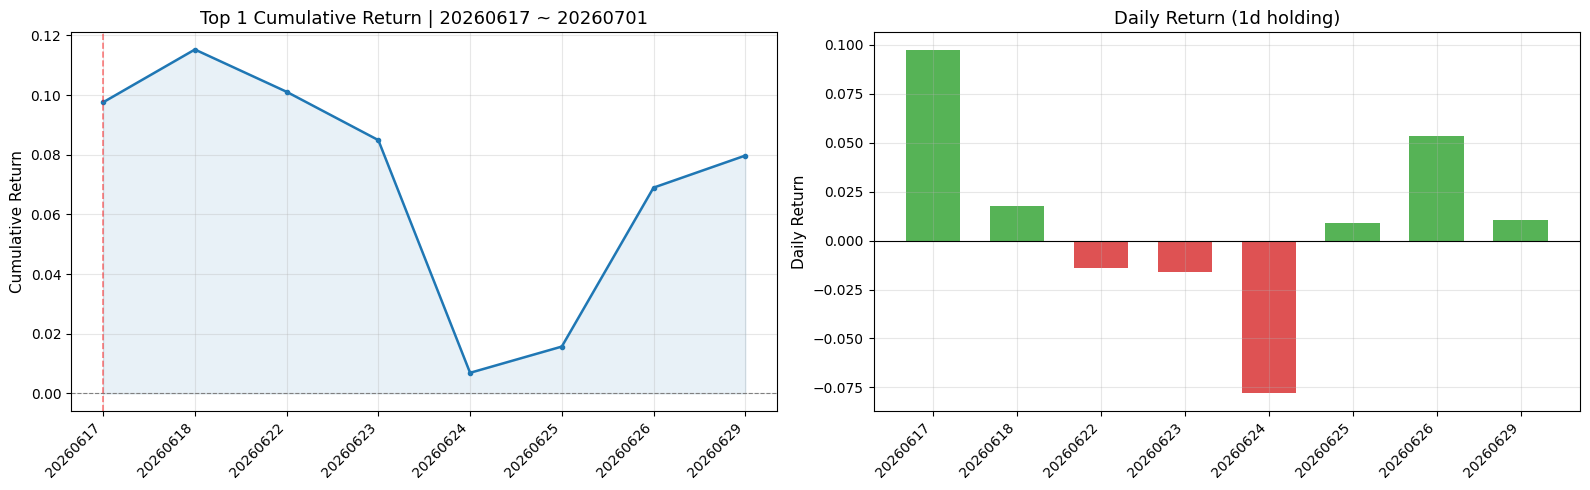


  Trade Log — Top 1 | 10 days | hold 1d | Returns from daily_adj close prices
 FactorDt   BuyDt     Code     Name    Score   BuyPrc   SellDt   SellPrc   Ret%   累加收益 
-------------------------------------------------------------------------------------------
  20260617  20260618  000811冰轮环境    +11.89   40.17  20260622    44.09  +9.76%    +9.76%
  20260618  20260622  000811冰轮环境    +19.48   44.09  20260623    44.87  +1.77%   +11.53%
  20260622  20260623  000519中兵红箭    +17.83   21.88  20260624    21.57  -1.42%   +10.11%
  20260623  20260624  002897意华股份    +14.44   93.16  20260625    91.65  -1.62%    +8.49%
  20260624  20260625  002897意华股份    +11.82   91.65  20260626    84.50  -7.80%    +0.69%
  20260625  20260626  000932华菱钢铁    +10.80    3.41  20260629     3.44  +0.88%    +1.57%
  20260626  20260629  603978深圳新星    +13.10   29.84  20260630    31.43  +5.33%    +6.90%
  20260629  20260630  002354天娱数科    +11.61    9.30  20260701     9.40  +1.08%    +7.97%
  20260630  20260701  000603盛达资源    +

In [8]:
# ============================================================
# Recent N-Day Backtest
# Dynamic tracking: return curve + daily trade log (symbol / price / return)
# ALL returns computed from actual price data (daily_adj), NOT from label
# ============================================================

N_LOOKBACK = 10  # <-- modify to adjust lookback window (trading days)

print(f"--- Recent {N_LOOKBACK}-Day Backtest ---")

# Ensure model_score_extended is available
try:
    _ = model_score_extended
except NameError:
    model_score_extended = model_score.copy()
    print("NOTE: model_score_extended not defined, using original model_score")

# ── Setup ──
close_map, prev_close_map, code_to_name = load_backtest_setup()

# ── Select window ──
all_dates = sorted(model_score_extended.index)
recent_dates = all_dates[-N_LOOKBACK:] if len(all_dates) >= N_LOOKBACK else all_dates
start_d, end_d = recent_dates[0], recent_dates[-1]

predicted_dates = [d for d in recent_dates if d not in set(model_score.index)]

print(f"Window : {start_d} ~ {end_d}  ({len(recent_dates)} trading days)")
if predicted_dates:
    tag = f"{predicted_dates[0]}~{predicted_dates[-1]}" if len(predicted_dates) > 1 else predicted_dates[0]
    print(f"  predicted: {len(predicted_dates)} days  ({tag})")

# ── Build trade log ──
trade_df, ret_valid, skip_total, skip_days = build_trade_log_df(
    model_score_extended, recent_dates, close_map, prev_close_map, code_to_name,
    top_n=TOP_N, exclude_limit_up=EXCLUDE_LIMIT_UP, label_horizon_days=LABEL_HORIZON_DAYS,
)

# ── Plot return curve ──
plot_backtest_curve(ret_valid, start_d, end_d, top_n=TOP_N,
                    label_horizon_days=LABEL_HORIZON_DAYS,
                    predicted_dates=predicted_dates if predicted_dates else None)

# ── Trade log table ──
print_trade_log_table(trade_df, ret_valid, recent_dates,
                      top_n=TOP_N, label_horizon_days=LABEL_HORIZON_DAYS)

# ── Summary statistics ──
print_backtest_summary(ret_valid, recent_dates, start_d, end_d, N_LOOKBACK,
                       top_n=TOP_N, label_horizon_days=LABEL_HORIZON_DAYS,
                       skip_total=skip_total, skip_days=skip_days,
                       exclude_limit_up=EXCLUDE_LIMIT_UP)


# 个股连续变化查询
输入股票代码和回顾天数 K，展示该股票在最新连续 K 个交易日内的打分与排名变化，并画图。


  Stock Trend: 603567 / 珍宝岛
  Lookback      : 10 days (20260618 ~ 20260702)
  Valid days    : 10
  Score change  : -0.3552 -> +5.9142  (+6.2695)
  Rank  change  : 1190 -> 44  (UP 1146)
  Score range   : -2.2282 ~ +5.9142
  Rank  range   : 42 ~ 1495

    BuyDate      Code     Score     Rank     Pct%   
  --------------------------------------------------
    20260702    603567     +5.9142      44     2.47%
    20260701    603567     +1.2337     654    36.70%
    20260630    603567     +5.3279      42     2.36%
    20260629    603567     +1.3031     606    34.01%
    20260626    603567     +3.2820     189    10.61%
    20260625    603567     +3.3091     177     9.93%
    20260624    603567     +1.5992     552    30.98%
    20260623    603567     -0.0956    1091    61.22%
    20260622    603567     -2.2282    1495    83.89%
    20260618    603567     -0.3552    1190    66.78%


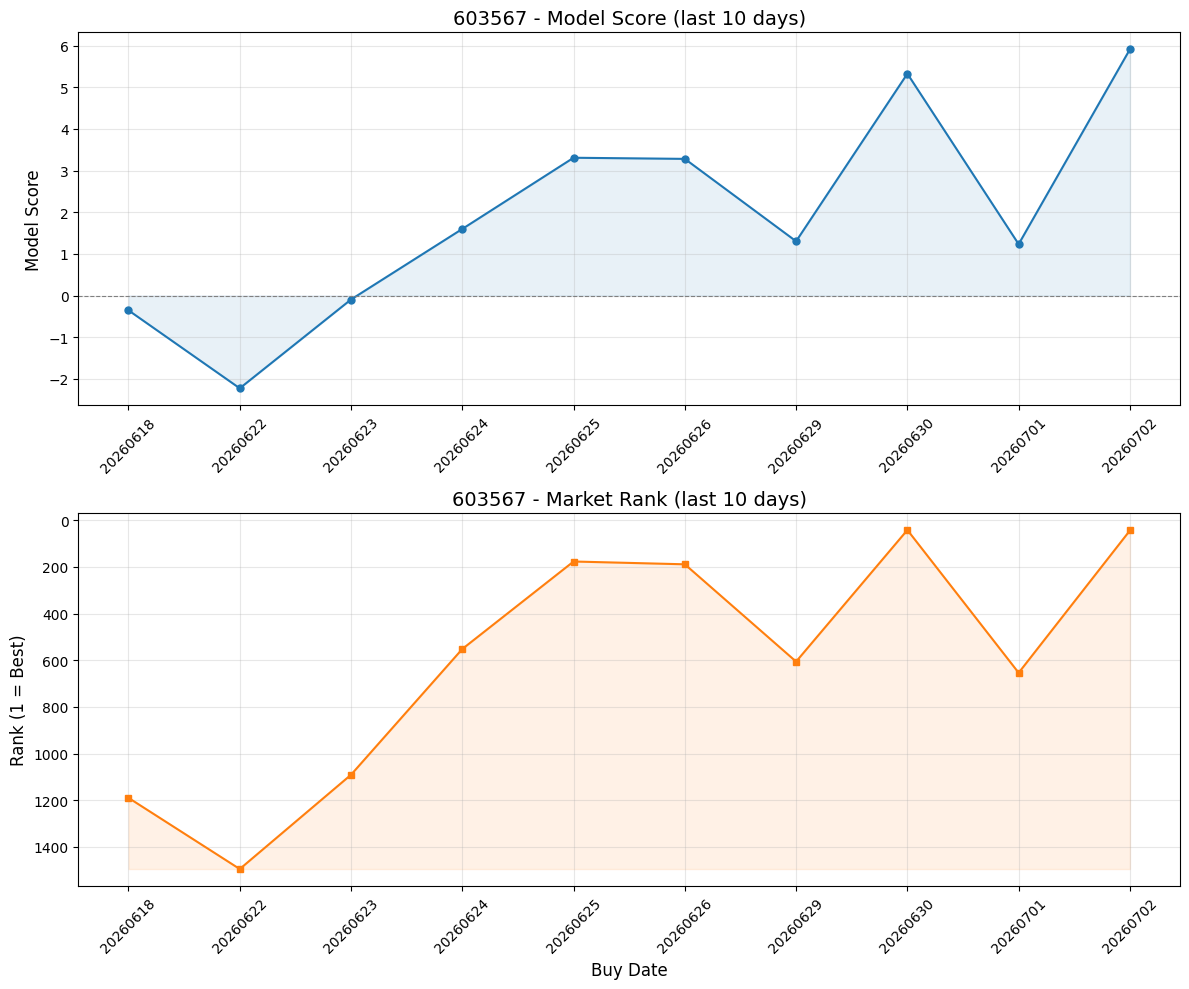

In [9]:
# ============================================================
# Stock Score Trend: query a stock's score & rank over the last K trading days
# Factor date +1 trading day = actual buy date, X-axis uses buy dates
# Usage: modify query_code and K, then run this cell
# ============================================================

query_code = '603567'   # <-- stock code (6 digits)
K = 10                  # <-- lookback window (trading days)

code_name = code_to_name.get(query_code, 'N/A')
scores_all = model_score_extended

# --- Last K trading days ---
all_dates = sorted(scores_all.index)
recent_dates = all_dates[-K:] if len(all_dates) >= K else all_dates

# --- Extract score & rank for each day ---
scores_list = []
ranks_list = []
pcts_list = []
for d in recent_dates:
    day_scores = scores_all.loc[d].dropna().sort_values(ascending=False)
    total = len(day_scores)
    if query_code in day_scores.index:
        s = day_scores[query_code]
        r = day_scores.index.get_loc(query_code) + 1
        scores_list.append(s)
        ranks_list.append(r)
        pcts_list.append(r / total * 100)
    else:
        scores_list.append(None)
        ranks_list.append(None)
        pcts_list.append(None)

valid_factor_dates = [d for i, d in enumerate(recent_dates) if scores_list[i] is not None]
valid_scores = [s for s in scores_list if s is not None]
valid_ranks = [r for r in ranks_list if r is not None]
valid_pcts = [p for p in pcts_list if p is not None]

# --- Date +1: factor date -> buy date ---
valid_buy_dates = [get_nth_next_trade_date(d, 1) for d in valid_factor_dates]
valid_buy_dates = [bd if bd is not None else d for bd, d in zip(valid_buy_dates, valid_factor_dates)]
valid_dates = valid_buy_dates

if len(valid_dates) == 0:
    print(f'{query_code} ({code_name}): no score data in the last {K} trading days.')
else:
    # --- Summary ---
    first_score, last_score = valid_scores[0], valid_scores[-1]
    change = last_score - first_score
    first_rank, last_rank = valid_ranks[0], valid_ranks[-1]
    rank_change = last_rank - first_rank
    rank_arrow = 'UP' if rank_change < 0 else ('DOWN' if rank_change > 0 else '-')

    print(f"\n{'=' * 60}")
    print(f"  Stock Trend: {query_code} / {code_name}")
    print(f"{'=' * 60}")
    print(f"  Lookback      : {K} days ({valid_dates[0]} ~ {valid_dates[-1]})")
    print(f"  Valid days    : {len(valid_dates)}")
    print(f"  Score change  : {first_score:+.4f} -> {last_score:+.4f}  ({change:+.4f})")
    print(f"  Rank  change  : {first_rank} -> {last_rank}  ({rank_arrow} {abs(rank_change)})")
    print(f"  Score range   : {min(valid_scores):+.4f} ~ {max(valid_scores):+.4f}")
    print(f"  Rank  range   : {min(valid_ranks)} ~ {max(valid_ranks)}")
    print(f"{'=' * 60}")

    # --- Detail table ---
    # Header & data alignment (right for numbers, center for date)
    print(f"\n  {'BuyDate':^12}{'Code':^10}{'Score':^10}{'Rank':^8}{'Pct%':^10}")
    print(f"  {'-' * 50}")
    for i, d in enumerate(valid_dates[::-1]):
        index = len(valid_dates) - 1 - i
        s = valid_scores[index]
        r = valid_ranks[index]
        p = valid_pcts[index]
        print(f"  {d:^12}{query_code:^10}{s:+10.4f}{r:>8}{p:>9.2f}%")

    # --- Plot: dual-axis score & rank ---
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

    # X-axis ticks (month marks for long periods, daily for short)
    seen_months = set()
    month_ticks, month_labels = [], []
    for i, d in enumerate(valid_dates):
        month = d[:6]
        if month not in seen_months:
            seen_months.add(month)
            month_ticks.append(i)
            month_labels.append(d)
    if len(valid_dates) <= 15:
        month_ticks = list(range(len(valid_dates)))
        month_labels = valid_dates

    # Panel 1: Score trend
    ax1.plot(valid_dates, valid_scores, marker='o', color='#1f77b4',
             linewidth=1.5, markersize=5)
    ax1.axhline(y=0, color='gray', linestyle='--', linewidth=0.8)
    ax1.fill_between(valid_dates, 0, valid_scores, alpha=0.1, color='#1f77b4')
    ax1.set_title(f'{query_code} - Model Score (last {K} days)', fontsize=14)
    ax1.set_ylabel('Model Score', fontsize=12)
    ax1.set_xticks(month_ticks)
    ax1.set_xticklabels(month_labels, rotation=45)
    ax1.grid(True, alpha=0.3)

    # Panel 2: Rank trend (inverted: 1=best at top)
    ax2.plot(valid_dates, valid_ranks, marker='s', color='#ff7f0e',
             linewidth=1.5, markersize=5)
    ax2.fill_between(valid_dates, max(valid_ranks), valid_ranks, alpha=0.1, color='#ff7f0e')
    ax2.invert_yaxis()
    ax2.set_title(f'{query_code} - Market Rank (last {K} days)', fontsize=14)
    ax2.set_ylabel('Rank (1 = Best)', fontsize=12)
    ax2.set_xlabel('Buy Date', fontsize=12)
    ax2.set_xticks(month_ticks)
    ax2.set_xticklabels(month_labels, rotation=45)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
